## Introdução

Uma maneira eficaz de evitar que consumidores tenham uma experiência ruim com o seu negócio é agir antes que a mesma ocorra. É possível prever, com base em algumas informações da jornada do cliente, quais deles terão uma boa e uma má experiência, e um dos melhores indicativos de como foi esta experiência é o NPS. Sendo assim, o objetivo deste notebook é analisar quais fatores são decisivos na experiência de um cliente, e prever, com base nessas variáveis, o possível NPS que este consumidor irá deixar no final de sua experiência.

## Importação das bibliotecas

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance

## Importação e pré processamento dos dados

In [55]:
# Importação dos dados
from pathlib import Path
BASE_DIR = Path.cwd().parent
df = pd.read_csv(BASE_DIR / 'data' / 'desafio_nps_fase_1.csv')

# Remoção das colunas de índices - são descartadas no treinamento do modelo para melhorar a generalização
df = df.drop(columns=['customer_id','order_id'])

# Remoção da coluna de recompra - será descartada para evitar data leakage, dado que é uma variável "do futuro" que não estará disponível no momento da predição
df = df.drop(columns=['repeat_purchase_30d'])

# Transformação de campos textuais em numéricos - o modelo não processa campos textuais
df['customer_region'] = df['customer_region'].astype('category').cat.codes

# Visualização dos dados
df.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,complaints_count,csat_internal_score
0,63,1,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3,6.5
1,20,4,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3,0.0
2,46,1,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7,1.5
3,52,0,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4,0.3
4,56,2,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3,7.9


## Escolha das variáveis para o treinamento dos modelos

### Análise da distribuição dos valores de NPS

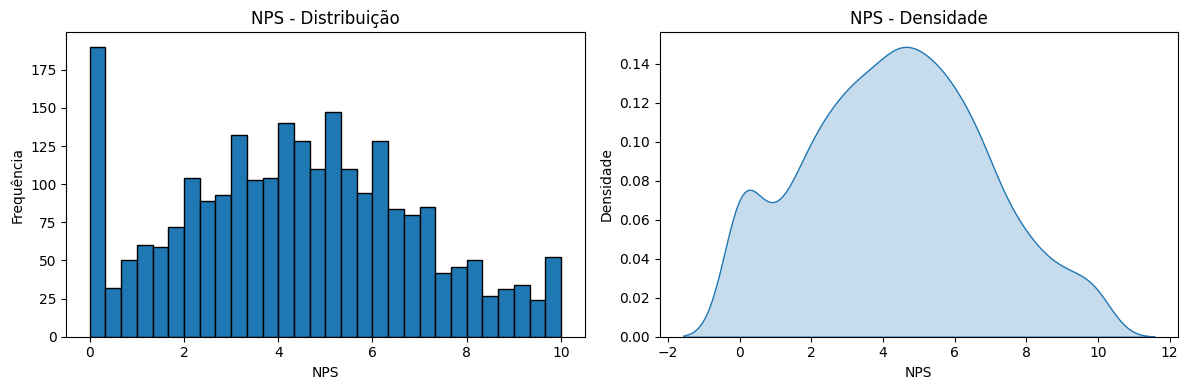

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df['nps_score'], bins=30, edgecolor='black')
axes[0].set_title('NPS - Distribuição')
axes[0].set_xlabel('NPS')
axes[0].set_ylabel('Frequência')

# KDE — distribuição suavizada
sns.kdeplot(df['nps_score'], ax=axes[1], fill=True)
axes[1].set_title('NPS - Densidade')
axes[1].set_xlabel('NPS')
axes[1].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

É possivel observar que os valores seguem uma **distribuição inflada em zero**, ou seja, parte dos dados seguem uma distribuição normal, e a outra parte está concentrada em um único valor, ou seja, zero.

Isto torna necessária a estratificação dos dados durante a divisão da base entre treino e teste, ou seja, a preservação da proporção de zeros em cada um dos datasets.

### Análise de correlação das variáveis independentes com a variável alvo

In [57]:
# Função para classificar as notas do NPS - apenas para fins visuais
def classificar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

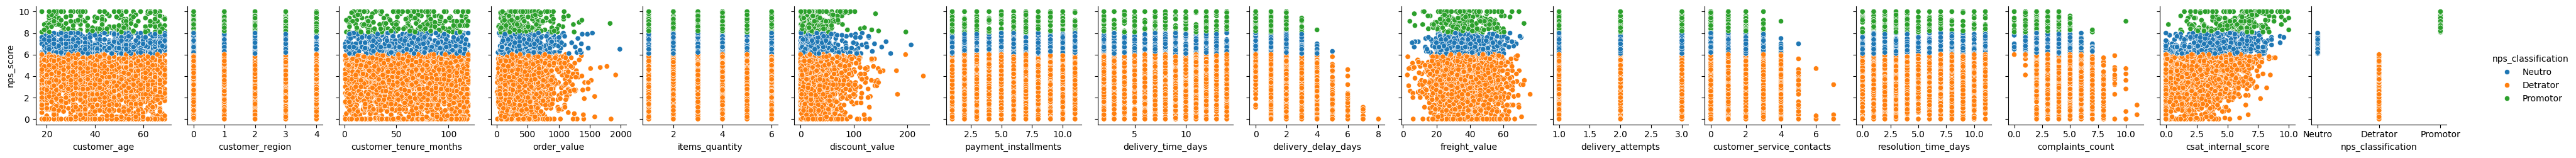

In [58]:
# Pairplot
df['nps_classification'] = df['nps_score'].apply(classificar_nps)

sns.pairplot(df, x_vars = df.drop(columns=['nps_score']).columns, y_vars = ['nps_score'], hue='nps_classification')

df = df.drop(columns=['nps_classification'])

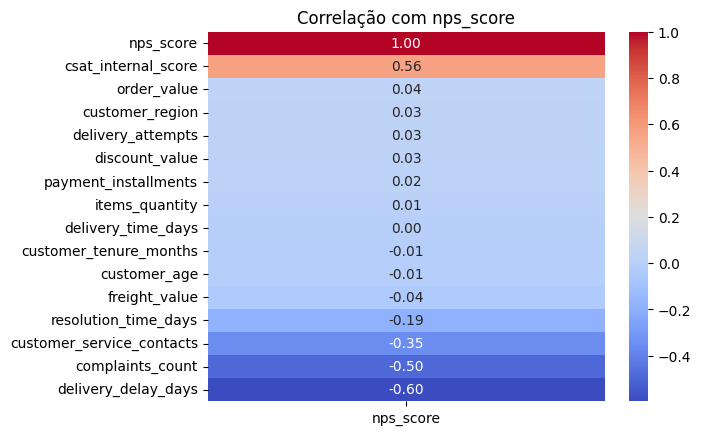

In [59]:
# Heatmap
corr = df.corr()[['nps_score']].sort_values('nps_score', ascending=False)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação com nps_score')
plt.show()

É possível observar que o NPS possui uma correlação positiva forte com a variável *csat_internal_score*, e uma correlação negativa forte com as variáveis *delivery_delay_days*, *complaints_count*, *costumer_service_contacts* e *resolution_time_days*, portanto, serão preservadas no dataset apenas estas variáveis.

In [60]:
# Seleção de variáveis indepententes que possuem uma correlação forte com a variável target
train_test_df = df[['nps_score','csat_internal_score','resolution_time_days','customer_service_contacts','complaints_count','delivery_delay_days']]
train_test_df.head()

,nps_score,csat_internal_score,resolution_time_days,customer_service_contacts,complaints_count,delivery_delay_days
0,6.9,6.5,4,0,3,2
1,2.4,0.0,10,0,3,4
2,4.8,1.5,5,4,7,1
3,5.9,0.3,11,1,4,2
4,6.1,7.9,0,1,3,1


### Divisão da base de treino e teste

In [61]:
# Divisão da base entre treino e teste
X = train_test_df.drop(columns=['nps_score'])
y = train_test_df['nps_score']

# Variável auxiliar para a estratificação
stratify_col = (y == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=stratify_col
)

## Modelos de regressão para predição de NPS

Para realizar a predição do NPS do consumidor, foi optado por utilizar modelos de regressão para prever o valor do NPS (0 a 10). Outra opção válida seria utilizar modelos classificação para categorizar os clientes entre detradores, neutros e promotores, porém, o valor bruto do NPS carrega informações mais assertivas do que apenas a categorização.

Como opções de modelos "baseline", foram escolhidos os modelos Ridge, Lasso e ElasticNet, principalmente pela sua simplicidade, baixa demanda computacional e rapidez no treinamento.

Como opção de modelo não linear, foi escolhido o XGBoost Regressor, que também é um modelo que exige pouco poder de processamento e é capaz de captar padrões menos lineares nos dados.

### Modelos lineares: Ridge, Lasso e ElasticNet

#### Treinamento dos modelos

Para comparar os diferentes modelos lineares e avaliar qual deles tem o melhor resultado com os nossos dados, e também para encontrar os melhores hiperparâmetros para os mesmos, foi utilizado o grid search no processo de treinamento.

In [62]:
# Pipeline com scaler + modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Scaler para normalização dos dados
    ('model', DummyRegressor())    # Definir qualquer modelo para iniciar a pipeline
])

# Grid de hiperparâmetros
param_grid = [
    {
        'model': [Ridge()],
        'model__alpha': [0.01, 0.1, 1, 10, 100]
    },
    {
        'model': [Lasso()],
        'model__alpha': [0.01, 0.1, 1, 10, 100]
    },
    {
        'model': [ElasticNet()],
        'model__alpha': [0.01, 0.1, 1, 10],
        'model__l1_ratio': [0.2, 0.5, 0.8]
    }
]

# Grid Search
grid_search_lin = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Treinamento do modelo
grid_search_lin.fit(X_train, y_train)

Fitting 5 folds for each of 22 candidates, totalling 110 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [Ridge()], 'model__alpha': [0.01, 0.1, ...]}, {'model': [Lasso()], 'model__alpha': [0.01, 0.1, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

#### Avaliação dos modelos

In [63]:
# Seleção do melhor modelo
print(f"Melhor modelo: {grid_search_lin.best_params_['model']}")
print(f"Melhor score (CV): {-grid_search_lin.best_score_:.4f}")

# Avaliação no conjunto de teste
y_pred = grid_search_lin.predict(X_test)
print("\nMétricas no teste:")
print(f"RMSE: {(mean_squared_error(y_test, y_pred)**1/2):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

Melhor modelo: Ridge()
Melhor score (CV): 2.9126

Métricas no teste:
RMSE: 1.2839
R²: 0.5726


Pode ser observado que o modelo com melhor desempenho foi o Ridge, que obteve um erro médio de 1,28 no valor do NPS.

#### Análise da importância das features

In [64]:
# Extrai o melhor modelo do grid search
best_model = grid_search_lin.best_estimator_['model']
best_scaler = grid_search_lin.best_estimator_['scaler']

# Coeficientes
feature_names = X.columns
coefficients = best_model.coef_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print(importance_df)

                     feature  coefficient  abs_coefficient
4        delivery_delay_days    -1.277558         1.277558
3           complaints_count    -0.621724         0.621724
2  customer_service_contacts    -0.374817         0.374817
1       resolution_time_days    -0.286056         0.286056
0        csat_internal_score     0.254285         0.254285


Pode ser observado que a feature mais relevante para o bom resultado do modelo é a quantidade de dias de atraso na entrega, seguido pelo número de reclamações.

### Modelo não linear: XGBoost

#### Treinamento do modelo

No treinamento do modelo não linear, também foi utilizado o Grid Search, para que sejam encontrados os melhores hiperparâmetros.

In [65]:
pipeline = Pipeline([
    ('model', XGBRegressor(random_state=30))
])

param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 1.0],
    'model__colsample_bytree': [0.7, 1.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.7, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messa

#### Avaliação do modelo

In [66]:
# Parâmetros do melhor modelo
print(f"Melhores hiperparâmetros: {grid_search.best_params_}")
print(f"MSE do melhor modelo: {-grid_search.best_score_:.4f}")

# Avaliação no conjunto de teste
y_pred = grid_search.predict(X_test)
print(f"MSE: {(mean_squared_error(y_test, y_pred)**1/2):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

Melhores hiperparâmetros: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.7}
MSE do melhor modelo: 2.8381
MSE: 1.2972
R²: 0.5682


Pode-se observar que o XGBoost teve um desempenho ligeiramente pior do que o Ridge. Isso pode se dar pelo fato de que o XGBoost é um modelo que se beneficia de grandes volumes de dados, o que não é o caso deste projeto, dado que o dataset é relativamente pequeno, e, pelas variáveis independentes terem um relacionamento majoritariamente linear com a variável alvo, um modelo linear deve ser suficiente para captar padrões nestes dados.

#### Análise da importância das features

In [67]:
# Modelo com melhor resultado
estimator = grid_search.best_estimator_['model']

feature_importance = estimator.feature_importances_
feature_names = X_train.columns

# Importância - "quantos % essa variável representa na importância total?"
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Permutation Importance - "se essa variável fosse removida do treinamento do modelo, qual seria o acréscimo/decréscimo no erro médio?"
perm_importance = permutation_importance(
    estimator,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)
perm_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

# Função para arredondar os valores de importância das features
def round_numeric_cols(df):

    numeric_cols = df.select_dtypes(include=['number']).columns
    for col in numeric_cols:
        df[col] = df[col].apply(lambda x: round(x, 2) if pd.notna(x) else x)
    return df

importance_df = round_numeric_cols(importance_df)
perm_importance_df = round_numeric_cols(perm_importance_df)

In [68]:
importance_df

,feature,importance
4,delivery_delay_days,0.48
3,complaints_count,0.24
0,csat_internal_score,0.18
2,customer_service_contacts,0.07
1,resolution_time_days,0.03


In [69]:
perm_importance_df

,feature,importance_mean,importance_std
4,delivery_delay_days,0.45,0.02
3,complaints_count,0.37,0.03
0,csat_internal_score,0.20,0.02
2,customer_service_contacts,0.03,0.01
1,resolution_time_days,0.00,0.00


É possível observar que as variáveis `delivery_delay_days` e `complaints_count`, assim como nos modelos lineares, também foram as variáveis mais decisivas para o bom desempenho do modelo não linear.

## Resultados

Para simular o funcionamento do modelo de predição em um ambiente produtivo, pode-se estimar quantos clientes detratores o modelo conseguiria prever.

In [70]:
# Junção da base de teste
detractor_df = pd.concat([X_test, y_test], axis=1)
X_test_detractors = detractor_df.drop(columns=['nps_score'])
y_test_detractors = detractor_df['nps_score']

# Predição do score de NPS dos clientes da base de teste
predict_detractors = grid_search_lin.predict(X_test_detractors)
predict_detractors_df = pd.DataFrame(data=predict_detractors, columns=['nps_score_pred'])

# Junção dos DataFrames para comparação
comparison_df = pd.concat([
    X_test_detractors.reset_index(drop=True),
    y_test_detractors.reset_index(drop=True),
    predict_detractors_df
], axis=1)

# Classificação dos valores de NPS
comparison_df['nps_classification'] = comparison_df['nps_score'].apply(classificar_nps)
comparison_df['nps_classification_pred'] = comparison_df['nps_score_pred'].apply(classificar_nps)

# Taxa de acerto geral
hit_rate = (comparison_df['nps_classification'] == comparison_df['nps_classification_pred']).mean()
print(f"Taxa de acerto: {hit_rate:.2%}")

# Detalhamento por classe
print(classification_report(
    comparison_df['nps_classification'],
    comparison_df['nps_classification_pred']
))

Taxa de acerto: 76.93%
              precision    recall  f1-score   support

    Detrator       0.87      0.91      0.89       569
      Neutro       0.36      0.40      0.38       125
    Promotor       0.71      0.18      0.29        56

    accuracy                           0.77       750
   macro avg       0.65      0.50      0.52       750
weighted avg       0.77      0.77      0.76       750



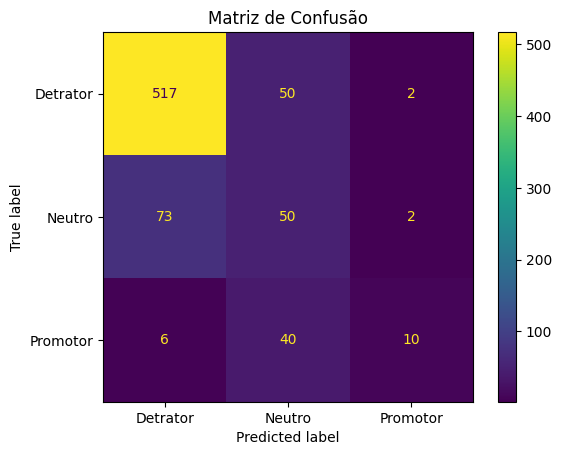

In [71]:
# Matriz de confusão do modelo
ConfusionMatrixDisplay.from_predictions(
    comparison_df['nps_classification'],
    comparison_df['nps_classification_pred'],
    display_labels=['Detrator', 'Neutro', 'Promotor']
)
plt.title("Matriz de Confusão")
plt.show()

Pode ser observado que o modelo tem um ótimo desempenho para prever clientes que se tornarão detratores, atingindo uma precisão de 87% para estes cenários. Porém, o modelo não apresenta um bom desempenho para classificar usuários neutros e promotores, o que pode ser explicado pelo fato da base de dados estar desbalanceada e conter mais detratores do que outros tipos de clientes. Lembrando que a estratificação do modelo foi feita não para equilibrar o número de clientes de cada classe de NPS, mas, sim, para equilibrar o número de clientes com nota igual a zero com aqueles com nota maior do que zero, considerando a distribuição inflada em zero que a base de dados apresenta.

## Conclusão

Levando em consideração que o grande objetivo destes modelos é prever quais consumidores se tornarão detratores, o erro médio de 1,28 atingido pelo modelo Ridge, por mais que seja um erro relativamente grande considerando a escala de 0 a 10 do NPS, se mostra suficiente para prever a maioria destes cenários extremos, onde os usuários se tornariam detratores e teriam notas muito baixas ou próximas de 0 no NPS.

Para validar essa hipótese, os scores previstos pelo modelo foram convertidos nas categorias do NPS: Detrator (≤6), Neutro (7–8) e Promotor (≥9), e comparados com as classificações reais da base de teste. O modelo atingiu uma taxa de acerto geral de 76,93%, com desempenho especialmente sólido na identificação de detratores, categoria de maior interesse para o negócio, alcançando precisão de 87% e recall de 91%, resultando em um f1-score de 0,89.

O desempenho inferior nas categorias Neutro e Promotor é esperado dado o desbalanceamento da base: 569 detratores contra apenas 56 promotores, porém, não compromete o objetivo principal do modelo, que é justamente antecipar quais clientes se consolidariam detratores.

Os modelos podem ser utilizados em ambiente produtivo pelos times de negócio e experiência do cliente para prever quais consumidores potencialmente se tornarão detratores, e, com base nisso, tomar ações antecipadas para que a experiência do usuário não seja negativa.

Uma oportunidade de melhoria para as predições é expandir a base de dados, incluindo variáveis como:
- se o problema foi resolvido
- se foi necessário o uso de um canal externo, e qual foi este canal
- Se houve devolução ou troca no pedido
- Se houve alguma avaria na entrega, e se o cliente recebeu alguma compensação por ela